In [1]:
# Importing necessary packages
import pandas as pd
from ultralytics import YOLO
import torch
import os
import seaborn
# import random
# from PIL import Image
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Checking if CUDA is available (for Nvidia GPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.cuda.empty_cache()
device

'cuda'

In [3]:
weights_path = os.path.join("..", "..", "..", "weights", "panicle_count_models", "y8_all_view_best.pt")
data_path = os.path.join("..", "..", "..", "sample_data", "raw_field_large_images")
weights_path, data_path

('..\\..\\..\\weights\\panicle_count_models\\y8_all_view_best.pt',
 '..\\..\\..\\sample_data\\raw_field_large_images')

img_size= (5157, 8111, 3)

WARNING imgsz=[5157] must be multiple of max stride 32, updating to [5184]
image 1/1 c:\GitHub_AI_Workshop\codes\1_panicle_count\2_inference\..\..\..\sample_data\raw_field_large_images\FN_PINK_KAFIR.JPG: 3296x5184 79 panicles, 370.8ms
Speed: 91.4ms preprocess, 370.8ms inference, 15.1ms postprocess per image at shape (1, 3, 3296, 5184)
Results saved to C:\GitHub_AI_Workshop\codes\1_panicle_count\2_inference\runs\detect\yv8_results\All_view_yolov8


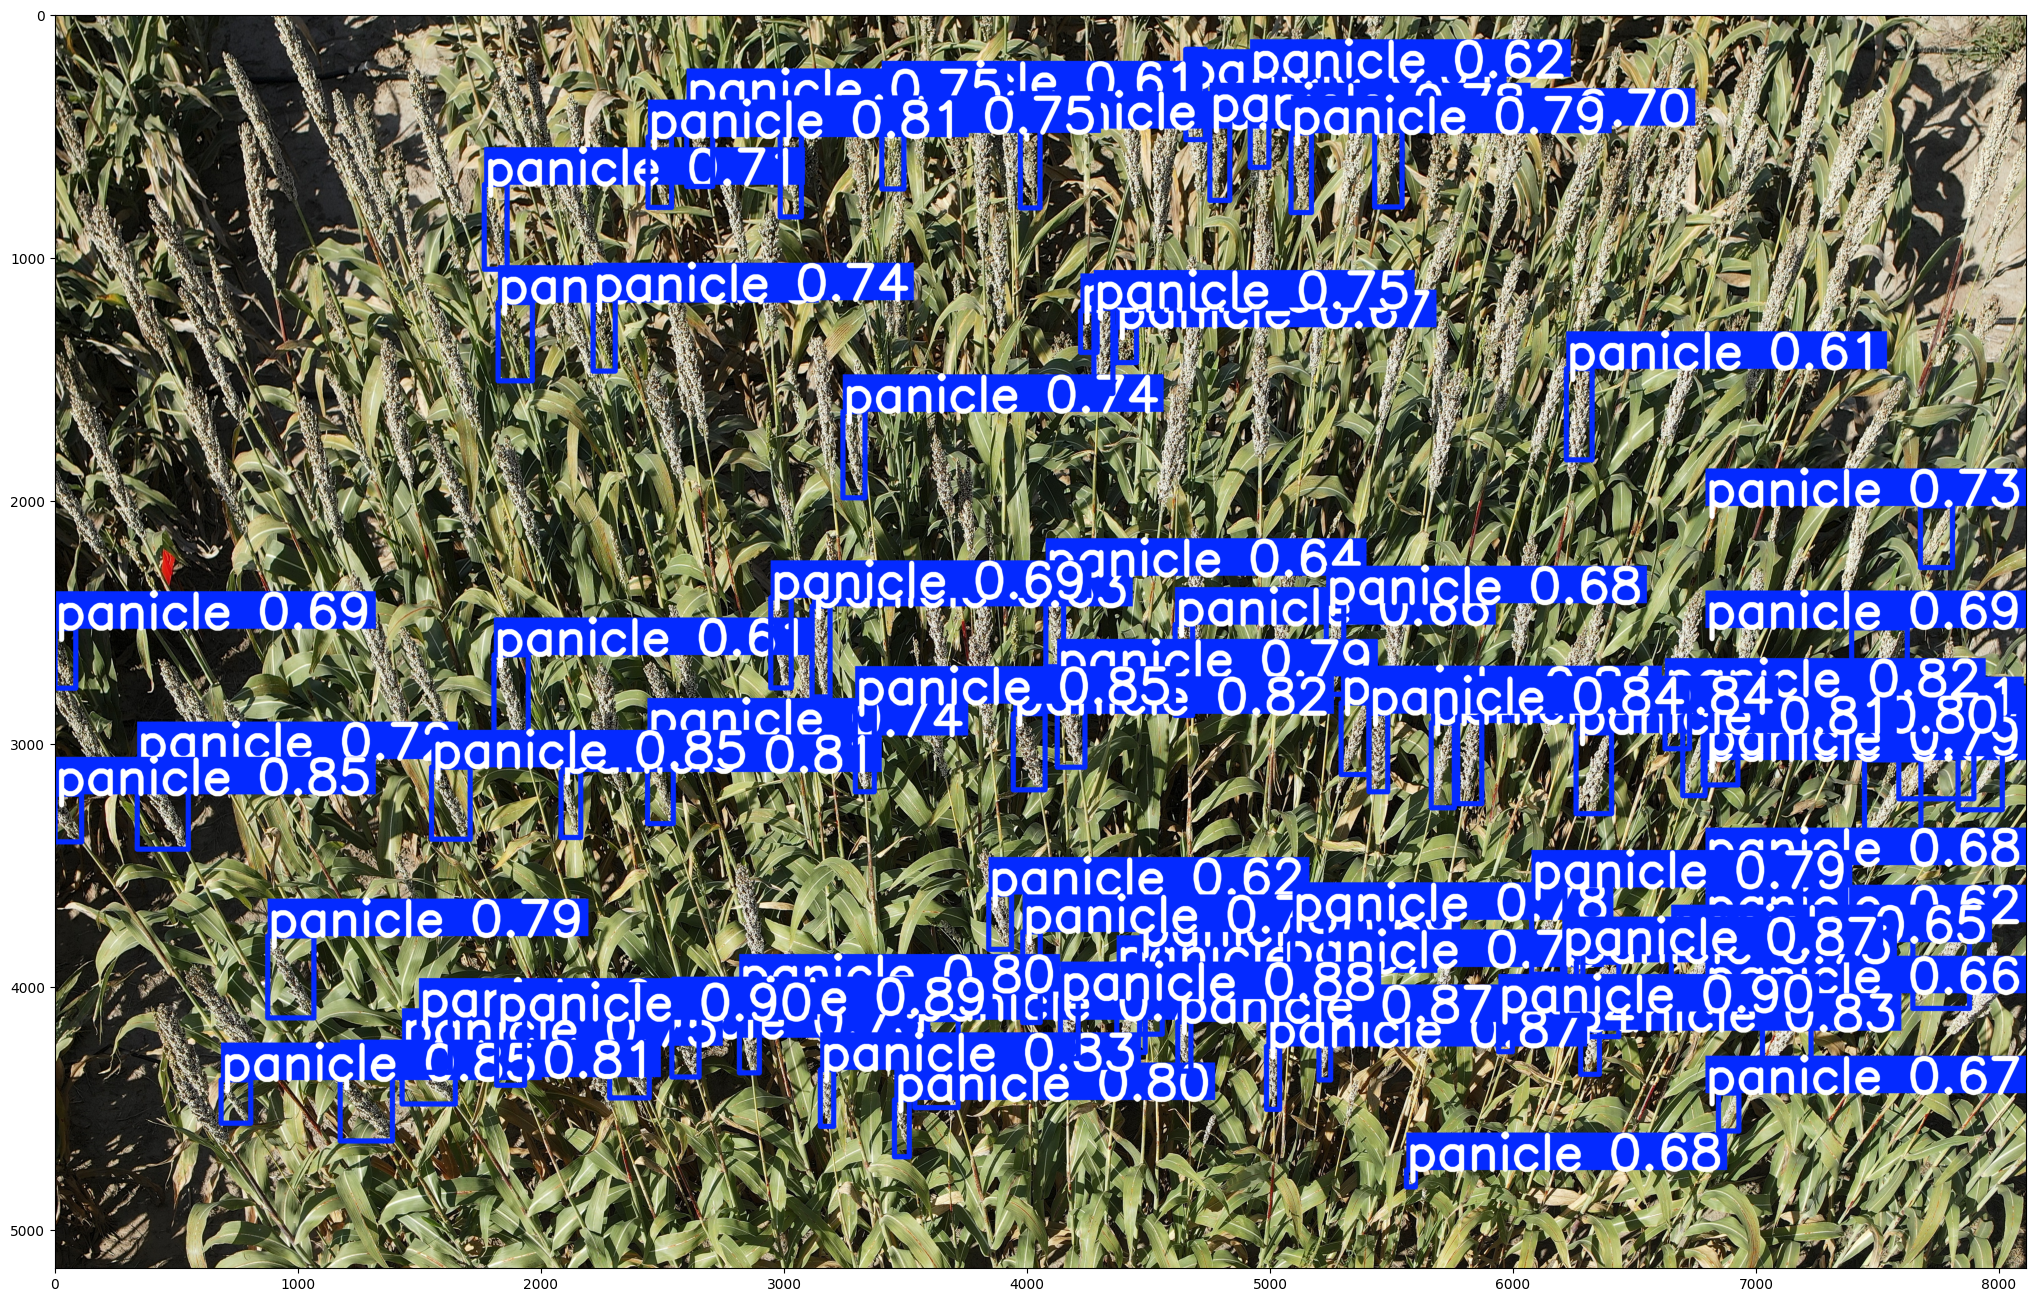

In [4]:
model = YOLO(weights_path)  # load a custom model
#imgsz = 2432 works best for most of the large images.
# Predict with the model
# results = model(r'C:\Users\mabdullahbari\OneDrive - Kansas State University\2024\DL_Sorghum\DL_Running_LM\panicle_head_2\FN_Image_Clip\B10001\FN_B10001.JPG', save=True, imgsz=5408, max_det = 3000, conf = 0.25, show_labels=False,show_conf=False) # predict on an image
# img=plt.imread('/home/mabdullahbari/South_Cropped/FS_6m_0001.JPG')

images = [filename for filename in os.listdir(data_path) if filename.lower().endswith('.jpg')]
sample_image = images[2]
sample_image_path = os.path.join(data_path, sample_image)
img = plt.imread(sample_image_path)

print("img_size=", img.shape)
results = model(sample_image_path, save=True, imgsz=img.shape[0], max_det = 3000, conf = 0.6, show_labels=False, show_conf=False,  project='yv8_results', name='All_view_yolov8') # predict on an image
base_width = 40
base_height = img.shape[0]/img.shape[1] * base_width
# results = model(r'ND_Full_Images\ND_6m_0001.JPG', save=True) # predict on an image
fig = plt.figure(figsize=(base_height, base_width)) #plt.figure(figsize=(8.192, 5.5460))
detect_img = results[0].plot()
detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)
plt.imshow(detect_img)
# plt.show()

img_size= (3800, 7638, 3)

WARNING imgsz=[3800] must be multiple of max stride 32, updating to [3808]
image 1/1 c:\GitHub_AI_Workshop\codes\1_panicle_count\2_inference\..\..\..\sample_data\raw_field_large_images\FN_Macia.JPG: 1920x3808 157 panicles, 156.5ms
Speed: 39.0ms preprocess, 156.5ms inference, 1.4ms postprocess per image at shape (1, 3, 1920, 3808)
Results saved to C:\GitHub_AI_Workshop\codes\1_panicle_count\2_inference\runs\detect\yv8_results\All_view_yolov8-2


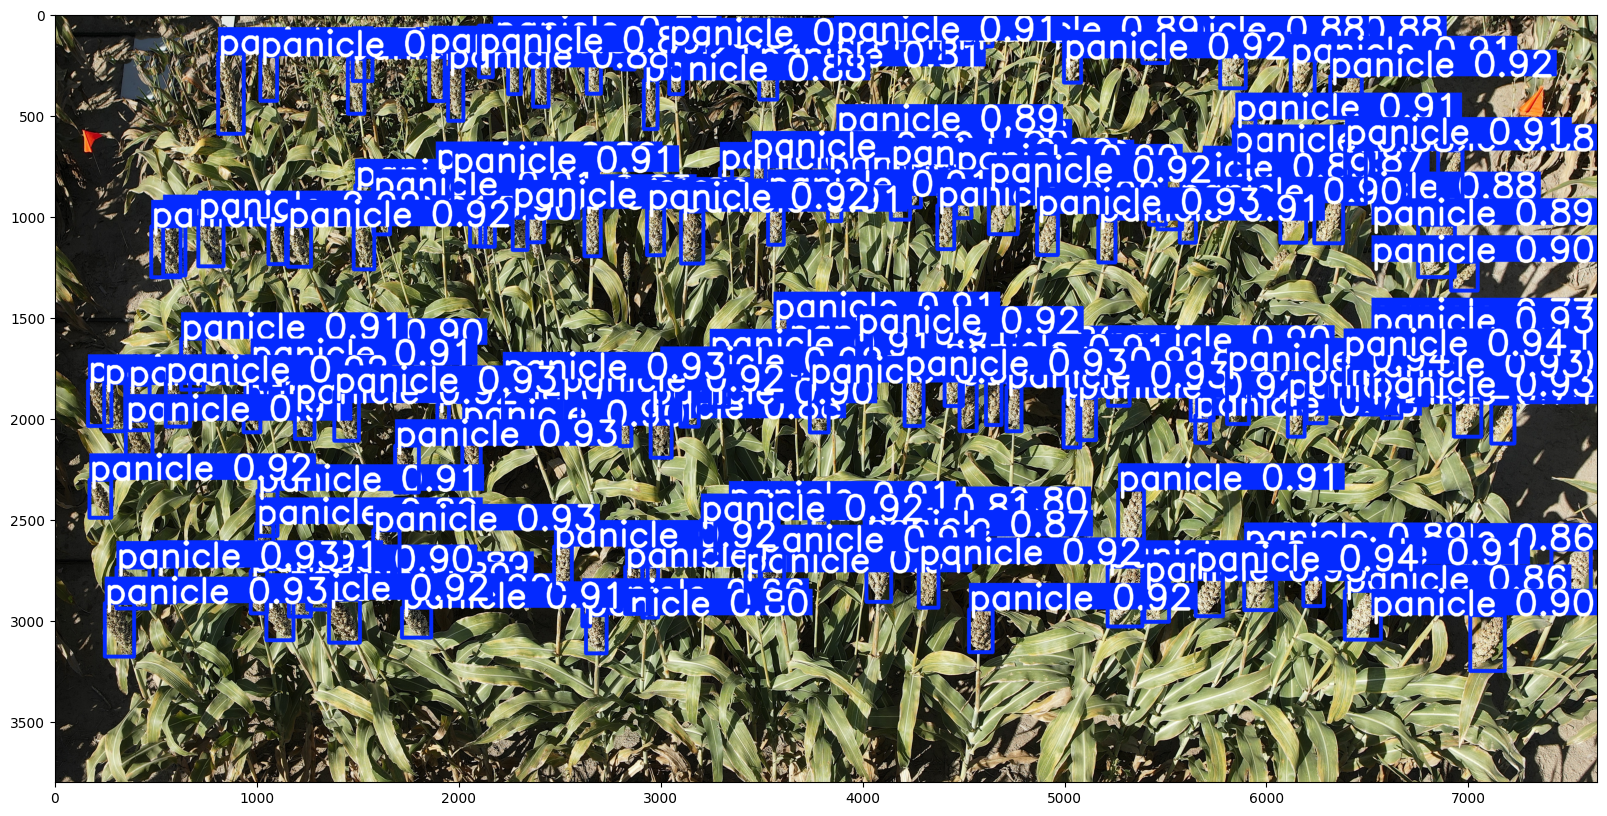

In [5]:
model = YOLO(weights_path)  # load a custom model
#imgsz = 2432 works best for most of the large images.
# Predict with the model
# results = model(r'C:\Users\mabdullahbari\OneDrive - Kansas State University\2024\DL_Sorghum\DL_Running_LM\panicle_head_2\FN_Image_Clip\B10001\FN_B10001.JPG', save=True, imgsz=5408, max_det = 3000, conf = 0.25, show_labels=False,show_conf=False) # predict on an image
# img=plt.imread('/home/mabdullahbari/South_Cropped/FS_6m_0001.JPG')

images = [filename for filename in os.listdir(data_path) if filename.lower().endswith('.jpg')]
sample_image = images[1]
sample_image_path = os.path.join(data_path, sample_image)
img = plt.imread(sample_image_path)

print("img_size=", img.shape)
results = model(sample_image_path, save=True, imgsz=img.shape[0], max_det = 3000, conf = 0.6, show_labels=False, show_conf=False,  project='yv8_results', name='All_view_yolov8') # predict on an image
base_width = 40
base_height = img.shape[0]/img.shape[1] * base_width
# results = model(r'ND_Full_Images\ND_6m_0001.JPG', save=True) # predict on an image
fig = plt.figure(figsize=(base_height, base_width)) #plt.figure(figsize=(8.192, 5.5460))
detect_img = results[0].plot()
detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)
plt.imshow(detect_img)
# plt.show()

In [6]:
img_folder=data_path
# img_names=os.listdir(img_folder)
img_names=sorted(images)
boxes_list=[]
# img_path=os.path.join(img_folder,img_names[0])
# print(img_path)
# print(img_names)
for img_name in img_names:
    # print(img_name)
    img_path=os.path.join(img_folder,img_name)
    img=plt.imread(img_path)
    print("img_size=", img.shape[0])
    results = model(img_path, save=True, imgsz=img.shape[0], max_det = 3000, conf = 0.6, show_labels=False, show_conf=False, project='yv8_results', name='All_view_yolov8') # predict on an image
    detect_img = results[0].plot()
    detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)
    boxes = results[0].boxes.xywh
    boxes_list.append(len(boxes))   

img_size= 1859

WARNING imgsz=[1859] must be multiple of max stride 32, updating to [1888]
image 1/1 c:\GitHub_AI_Workshop\codes\1_panicle_count\2_inference\..\..\..\sample_data\raw_field_large_images\FN_BTx2752.JPG: 640x1888 188 panicles, 209.1ms
Speed: 8.9ms preprocess, 209.1ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 1888)
Results saved to C:\GitHub_AI_Workshop\codes\1_panicle_count\2_inference\runs\detect\yv8_results\All_view_yolov8-3
img_size= 3800

WARNING imgsz=[3800] must be multiple of max stride 32, updating to [3808]
image 1/1 c:\GitHub_AI_Workshop\codes\1_panicle_count\2_inference\..\..\..\sample_data\raw_field_large_images\FN_Macia.JPG: 1920x3808 157 panicles, 154.7ms
Speed: 39.9ms preprocess, 154.7ms inference, 1.1ms postprocess per image at shape (1, 3, 1920, 3808)
Results saved to C:\GitHub_AI_Workshop\codes\1_panicle_count\2_inference\runs\detect\yv8_results\All_view_yolov8-4
img_size= 5157

WARNING imgsz=[5157] must be multiple of max stride 32, upd

In [7]:
panicles_dic={'Image_Name':img_names,
             'Number_Panicles':boxes_list}
panicles_df=pd.DataFrame(panicles_dic)
panicles_df

,Image_Name,Number_Panicles
0,FN_BTx2752.JPG,188
1,FN_Macia.JPG,157
2,FN_PINK_KAFIR.JPG,79
3,FS_6m_0001.JPG,196
4,FS_6m_0002.JPG,142
5,FS_6m_0003.JPG,133
6,ND_6m_0001.JPG,165
7,ND_6m_0002.JPG,127
8,ND_6m_0003.JPG,154


In [ ]:
os.getcwd()
csv_path = os.path.join(
    os.getcwd(),
    "All_View_Y8_Panicle_Count.csv"
)

df.to_csv(csv_path, index=False)

print(f"CSV saved successfully at: {csv_path}")

In [ ]:
# # csv_path = os.path.join('yv8_results', 'All_View_Y8_Panicle_Count.csv')
# # panicles_df.to_csv(csv_path, index=False)
# panicles_df.to_csv("All_View_Y8_Panicle_Count.csv", index=False)